In [27]:
!pip install torch torchvision matplotlib onnxscript

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_data = datasets.ImageFolder("/content/drive/MyDrive/PyTorchONNX/data/train", transform=transform)
test_data = datasets.ImageFolder("/content/drive/MyDrive/PyTorchONNX/data/test", transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32)

class FruitCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = FruitCNN(len(train_data.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_acc_list = []
test_acc_list = []

epochs = 10
for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")
torch.save(model.state_dict(), "fruit_cnn.pth")
print(train_data.classes)
print(len(train_data))

Epoch 1: Train=33.33% | Test=66.67%
Epoch 2: Train=66.67% | Test=66.67%
Epoch 3: Train=66.67% | Test=66.67%
Epoch 4: Train=66.67% | Test=66.67%
Epoch 5: Train=66.67% | Test=73.33%
Epoch 6: Train=73.33% | Test=80.00%
Epoch 7: Train=80.00% | Test=80.00%
Epoch 8: Train=80.00% | Test=80.00%
Epoch 9: Train=80.00% | Test=80.00%
Epoch 10: Train=80.00% | Test=93.33%
['apple', 'banana', 'non-fruit', 'orange']
15


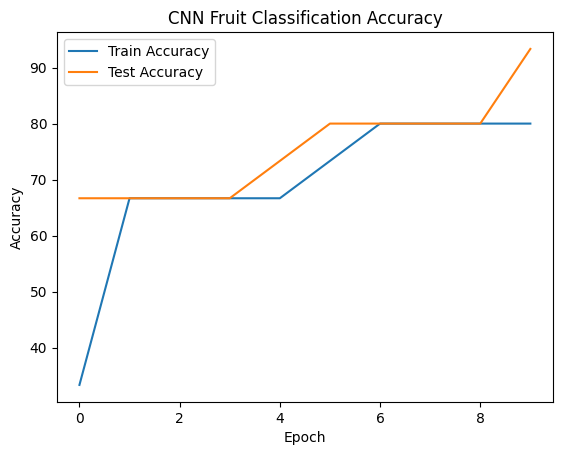

In [35]:
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Fruit Classification Accuracy")
plt.show()

In [33]:
dummy_input = torch.randn(1, 3, 64, 64).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "fruit_cnn.onnx",
    input_names=["input"],
    output_names=["output"]
)

W0417 01:24:18.789000 33051 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 01:24:18.791000 33051 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 01:24:18.793000 33051 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 01:24:18.796000 33051 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `FruitCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FruitCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,64,64]>
            ),
            outputs=(
                %"output"<FLOAT,[1,4]>
            ),
            initializers=(
                %"conv.0.weight"<FLOAT,[16,3,3,3]>{TorchTensor(...)},
                %"conv.0.bias"<FLOAT,[16]>{TorchTensor(...)},
                %"conv.3.weight"<FLOAT,[32,16,3,3]>{TorchTensor(...)},
                %"conv.3.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"conv.6.weight"<FLOAT,[64,32,3,3]>{TorchTensor(...)},
                %"conv.6.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"fc.1.weight"<FLOAT,[128,4096]>{TorchTensor(...)},
                %"fc.1.bias"<FLOAT,[128]>{TorchTensor(...)},
  